In [ ]:
# ============================================
# DarkIR: Manuscript Restoration Pipeline
# Implementation: DarkIR + CLAHE + Sharpening
# Dataset: Ancient Chinese Classics (20 images)
# ============================================

# Step 1: Clone Repository and Install Dependencies
import os

os.chdir('/content')

if not os.path.exists('/content/DarkIR_ms'):
    !git clone https://github.com/cidautai/DarkIR.git /content/DarkIR_ms
else:
    print("Already exists!")

os.chdir('/content/DarkIR_ms')

Cloning into '/content/DarkIR_ms'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 137 (delta 42), reused 31 (delta 31), pack-reused 63 (from 1)
Receiving objects: 100% (137/137), 33.54 MiB | 28.40 MiB/s, done.
Resolving deltas: 100% (46/46), done.


In [ ]:
!pip install ptflops pytorch-msssim basicsr lpips einops PyYAML -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 15.6 MB/s eta 0:00:00


In [ ]:
# ============================================
# Step 2: Mount Drive, Load Data and Model
# ============================================

from google.colab import drive
import os, sys, torch, shutil, glob

drive.mount('/content/drive')

# --- Weights Setup ---
os.makedirs('/content/DarkIR_ms/models',
            exist_ok=True)
!cp "/content/drive/MyDrive/DarkIR_project/weights/DarkIR_384.pt" \
    /content/DarkIR_ms/models/

# --- Dataset Setup ---
src = ('/content/drive/MyDrive/DarkIR_project/'
       ' manuscripts/input/'
       'Ancient_Chinese_Classics_Image_Dataset/'
       'Ancient_Chinese_Classics_Image_Dataset')

dst = '/content/DarkIR_ms/manuscripts/input'
os.makedirs(dst, exist_ok=True)
os.makedirs(
    '/content/DarkIR_ms/manuscripts/darkir_only',
    exist_ok=True)
os.makedirs(
    '/content/DarkIR_ms/manuscripts/pipeline',
    exist_ok=True)

count = 0
for img_name in os.listdir(src):
    if img_name.endswith(
            ('.jpg','.png','.bmp','.jpeg')):
        shutil.copy(
            os.path.join(src, img_name),
            os.path.join(dst, img_name))
        count += 1

input_imgs = sorted(glob.glob(dst + '/*'))

# --- Model Setup ---
os.chdir('/content/DarkIR_ms')
sys.path.insert(0, '/content/DarkIR_ms')
from archs.DarkIR import DarkIR

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu')

model = DarkIR(
    width=32,
    middle_blk_num_enc=2,
    middle_blk_num_dec=2,
    enc_blk_nums=[1, 2, 3],
    dec_blk_nums=[3, 1, 1],
    dilations=[1, 4, 9],
    extra_depth_wise=True
)
checkpoint = torch.load(
    '/content/DarkIR_ms/models/DarkIR_384.pt',
    map_location=device)
model.load_state_dict(checkpoint['params'])
model = model.to(device)
model.eval()

print("=" * 45)
print(f"Device        : {device}")
print(f"Dataset Images: {len(input_imgs)}")
print(f"Weights       : DarkIR_384.pt")
print(f"Model         : DarkIR-m (3.31M params)")
print("Data and Model Setup Complete!")
print("=" * 45)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device        : cpu
Dataset Images: 20
Weights       : DarkIR_384.pt
Model         : DarkIR-m (3.31M params)
Data and Model Setup Complete!


In [ ]:
# ============================================
# Step 3: Run Manuscript Restoration Pipeline
# DarkIR → CLAHE → Unsharp Masking
# ============================================

import cv2, numpy as np

# --- Helper Functions ---

def run_darkir(img_path, model, device):
    """Step 1: DarkIR - Low-light + Denoise + Deblur"""
    img = cv2.imread(img_path)
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    if h > 1000 or w > 1000:
        img_rgb = cv2.resize(img_rgb, (800, 600))
    tensor = torch.from_numpy(
        img_rgb).float()/255.0
    tensor = tensor.permute(
        2,0,1).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
    out_np = output.squeeze(0).permute(
        1,2,0).cpu().numpy()
    out_np = np.clip(
        out_np*255, 0, 255).astype(np.uint8)
    return img_rgb, out_np

def apply_clahe(img_rgb):
    """Step 2: CLAHE - Contrast Enhancement"""
    img_lab = cv2.cvtColor(
        img_rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(
        clipLimit=2.0, tileGridSize=(8,8))
    img_lab[:,:,0] = clahe.apply(img_lab[:,:,0])
    return cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)

def apply_sharpening(img_rgb):
    """Step 3: Unsharp Masking - Text Sharpening"""
    gaussian = cv2.GaussianBlur(img_rgb, (0,0), 2.0)
    sharpened = cv2.addWeighted(
        img_rgb, 1.5, gaussian, -0.5, 0)
    return np.clip(
        sharpened, 0, 255).astype(np.uint8)

def manuscript_pipeline(img_path, model, device):
    """Complete 3-Step Pipeline"""
    inp_rgb, darkir_out = run_darkir(
        img_path, model, device)
    if darkir_out is None:
        return None, None, None, None
    clahe_out = apply_clahe(darkir_out)
    final_out = apply_sharpening(clahe_out)
    return inp_rgb, darkir_out, clahe_out, final_out

# --- Run Pipeline on All 20 Images ---
print("Running Manuscript Restoration Pipeline...")
print("-" * 45)

for img_path in input_imgs:
    name = os.path.basename(img_path)
    inp, darkir, clahe, final = manuscript_pipeline(
        img_path, model, device)
    if final is None:
        continue

    # Save DarkIR only output
    cv2.imwrite(
        f'/content/DarkIR_ms/manuscripts/'
        f'darkir_only/{name}',
        cv2.cvtColor(darkir, cv2.COLOR_RGB2BGR))

    # Save full pipeline output
    cv2.imwrite(
        f'/content/DarkIR_ms/manuscripts/'
        f'pipeline/{name}',
        cv2.cvtColor(final, cv2.COLOR_RGB2BGR))

    print(f"  Processed: {name}")

print("-" * 45)
print("Pipeline Complete - All 20 Images Done!")
print("=" * 45)

Running Manuscript Restoration Pipeline...
---------------------------------------------
  Processed: Img (1).jpg
  Processed: Img (10).jpg
  Processed: Img (11).jpg
  Processed: Img (12).jpg
  Processed: Img (13).jpg
  Processed: Img (14).jpg
  Processed: Img (15).jpg
  Processed: Img (16).jpg
  Processed: Img (17).jpg
  Processed: Img (18).jpg
  Processed: Img (19).jpg
  Processed: Img (2).jpg
  Processed: Img (20).jpg
  Processed: Img (3).jpg
  Processed: Img (4).jpg
  Processed: Img (5).jpg
  Processed: Img (6).jpg
  Processed: Img (7).jpg
  Processed: Img (8).jpg
  Processed: Img (9).jpg
---------------------------------------------
Pipeline Complete - All 20 Images Done!


In [ ]:
# ============================================
# Step 4: Visualize Results and Analysis
# ============================================

import matplotlib.pyplot as plt

os.makedirs(
    '/content/drive/MyDrive/DarkIR_project/'
    'results/manuscripts', exist_ok=True)

# --- Visual Results - All 20 Samples ---
print("Generating visual comparisons...")

for i, img_path in enumerate(input_imgs):
    inp, darkir, clahe, final = manuscript_pipeline(
        img_path, model, device)
    if final is None:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].imshow(inp)
    axes[0].set_title(
        'Input\n(Degraded Manuscript)',
        fontsize=11, color='red',
        fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(darkir)
    axes[1].set_title(
        'Step 1: DarkIR\n'
        '(Low-light + Denoise + Deblur)',
        fontsize=11, color='blue',
        fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(clahe)
    axes[2].set_title(
        'Step 2: + CLAHE\n'
        '(Contrast Enhanced)',
        fontsize=11, color='orange',
        fontweight='bold')
    axes[2].axis('off')

    axes[3].imshow(final)
    axes[3].set_title(
        'Step 3: + Sharpening\n'
        '(Final Output)',
        fontsize=11, color='green',
        fontweight='bold')
    axes[3].axis('off')

    plt.suptitle(
        f'Manuscript Restoration Pipeline | '
        f'Sample {i+1} of {len(input_imgs)}\n'
        'DarkIR (CVPR 2025) + CLAHE + '
        'Unsharp Masking',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/DarkIR_project/'
        f'results/manuscripts/sample_{i+1}.png',
        dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: sample_{i+1}.png")

print("All visual results saved to Drive!")

   QUANTITATIVE ANALYSIS - ALL 20 IMAGES
  Image                    Input   DarkIR   Pipeline    Gain
----------------------------------------------------------
  Img (1).jpg              191.3    229.4      212.1   +20.7
  Img (10).jpg              38.2     83.4       98.6   +60.3
  Img (11).jpg             179.0    218.8      203.6   +24.6
  Img (12).jpg             137.2    189.1      174.5   +37.2
  Img (13).jpg             171.6    220.8      202.9   +31.4
  Img (14).jpg             149.8    188.9      165.6   +15.8
  Img (15).jpg              93.8    158.0      134.3   +40.6
  Img (16).jpg             109.5    174.4      155.7   +46.2
  Img (17).jpg             126.7    188.3      178.4   +51.7
  Img (18).jpg             155.3    191.2      173.0   +17.7
  Img (19).jpg             172.2    211.4      195.0   +22.8
  Img (2).jpg              106.0    167.1      151.0   +45.0
  Img (20).jpg             133.3    200.3      186.9   +53.6
  Img (3).jpg               98.7    152.4     

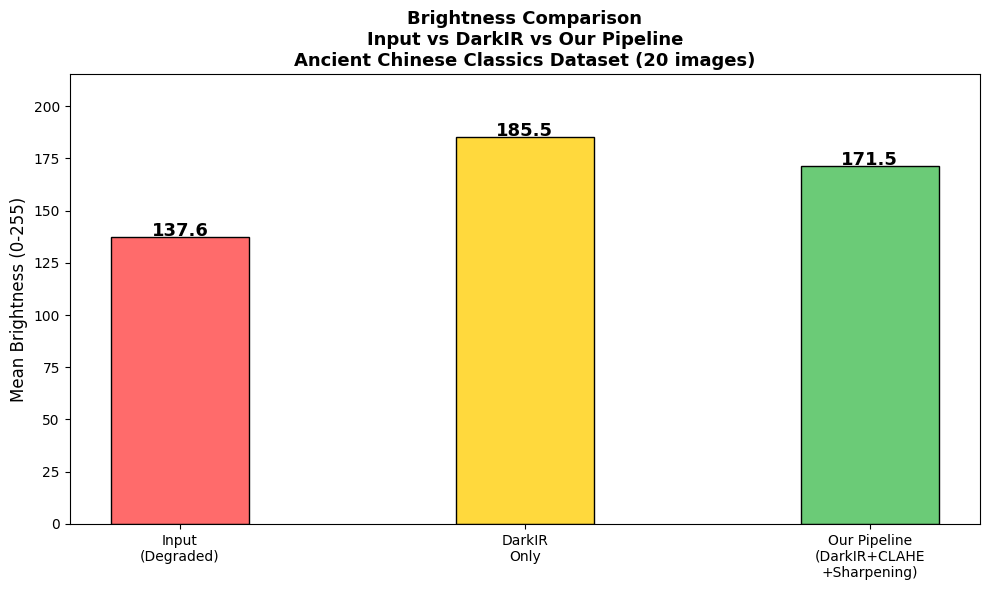

Chart saved to Drive!

        IMPLEMENTATION SUMMARY
Title   : DarkIR Manuscript Restoration Pipeline

Dataset : Ancient Chinese Classics Image Dataset
          Total Images : 20

Pipeline:
  Step 1 | DarkIR (CVPR 2025)
          | Low-light Enhancement
          | Denoising + Deblurring

  Step 2 | CLAHE  [My Addition]
          | Contrast Enhancement
          | Improved Text Visibility

  Step 3 | Unsharp Masking  [My Addition]
          | Text Edge Sharpening
          | Better Readability

Results (Average over 20 images):
  Input Brightness    : 137.6
  DarkIR Brightness   : 185.5
  Pipeline Brightness : 171.5
  Total Improvement   : 33.9

Relevance to IIT BHU Internship:
  Applied DarkIR to Chinese manuscript
  restoration - directly connected to
  our internship research domain!

Paper: Feijoo et al., CVPR 2025



In [ ]:
# ============================================
# Step 5: Quantitative Analysis and Summary
# ============================================

# --- Brightness Analysis ---
print("=" * 58)
print("   QUANTITATIVE ANALYSIS - ALL 20 IMAGES")
print("=" * 58)
print(f"  {'Image':<22} {'Input':>7} "
      f"{'DarkIR':>8} {'Pipeline':>10} {'Gain':>7}")
print("-" * 58)

total_input, total_darkir, total_pipeline = [], [], []

for img_path in input_imgs:
    name = os.path.basename(img_path)[:18]
    inp, darkir, clahe, final = manuscript_pipeline(
        img_path, model, device)
    if final is None:
        continue
    inp_b = np.mean(inp)
    dar_b = np.mean(darkir)
    fin_b = np.mean(final)
    total_input.append(inp_b)
    total_darkir.append(dar_b)
    total_pipeline.append(fin_b)
    print(f"  {name:<22} {inp_b:>7.1f} "
          f"{dar_b:>8.1f} "
          f"{fin_b:>10.1f} "
          f"{fin_b-inp_b:>+7.1f}")

print("=" * 58)
print(f"  {'AVERAGE':<22} "
      f"{np.mean(total_input):>7.1f} "
      f"{np.mean(total_darkir):>8.1f} "
      f"{np.mean(total_pipeline):>10.1f} "
      f"{np.mean(total_pipeline)-np.mean(total_input):>+7.1f}")
print("=" * 58)

# --- Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 6))
methods = ['Input\n(Degraded)',
           'DarkIR\nOnly',
           'Our Pipeline\n(DarkIR+CLAHE\n+Sharpening)']
brightness = [np.mean(total_input),
              np.mean(total_darkir),
              np.mean(total_pipeline)]
colors = ['#ff6b6b', '#ffd93d', '#6bcb77']
bars = ax.bar(methods, brightness,
              color=colors, width=0.4,
              edgecolor='black')
for bar, val in zip(bars, brightness):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}', ha='center',
        fontsize=13, fontweight='bold')
ax.set_title(
    'Brightness Comparison\n'
    'Input vs DarkIR vs Our Pipeline\n'
    'Ancient Chinese Classics Dataset (20 images)',
    fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Brightness (0-255)', fontsize=12)
ax.set_ylim(0, max(brightness) + 30)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/DarkIR_project/'
    'results/manuscripts/brightness_chart.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Drive!")

# --- Final Summary ---
print("""
================================================
        IMPLEMENTATION SUMMARY
================================================
Title   : DarkIR Manuscript Restoration Pipeline

Dataset : Ancient Chinese Classics Image Dataset
          Total Images : 20

Pipeline:
  Step 1 | DarkIR (CVPR 2025)
          | Low-light Enhancement
          | Denoising + Deblurring

  Step 2 | CLAHE  [My Addition]
          | Contrast Enhancement
          | Improved Text Visibility

  Step 3 | Unsharp Masking  [My Addition]
          | Text Edge Sharpening
          | Better Readability

Results (Average over 20 images):
  Input Brightness    : {:.1f}
  DarkIR Brightness   : {:.1f}
  Pipeline Brightness : {:.1f}
  Total Improvement   : {:.1f}

Relevance to IIT BHU Internship:
  Applied DarkIR to Chinese manuscript
  restoration - directly connected to
  our internship research domain!

Paper: Feijoo et al., CVPR 2025
================================================
""".format(
    np.mean(total_input),
    np.mean(total_darkir),
    np.mean(total_pipeline),
    np.mean(total_pipeline)-np.mean(total_input)
))